# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023.

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**

In this summative assessment you will demonstrate your ability to:
- **Use Pandas to load, inspect, and clean the dataset appropriately.**
- **Transform relevant columns to create measures that address the problem at hand.**
- conduct EDA: visualization and statistical measures to systematically understand the structure of the data
- recommend a set of airplanes and makes conforming to the client's request and identify at least *two* factors contributing to airplane safety. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.

### Make relevant library imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Data Loading and Inspection

### Load in data from the relevant directory and inspect the dataframe.
- inspect NaNs, datatypes, and summary statistics

In [2]:
# Download the dataset from Kaggle. Falls back to a local copy at
# data/AviationData.csv if kagglehub / Kaggle credentials aren't available
# (e.g. when this notebook is run on GitHub or in a restricted environment).
import os

try:
    import kagglehub
    path = kagglehub.dataset_download("mos3santos/acidentes-de-aviao-at-2023")
    print("Path to dataset files:", path)
except Exception as e:
    print(f"kagglehub download unavailable ({e!r}); falling back to local data/AviationData.csv")
    path = "data"


kagglehub download unavailable (ModuleNotFoundError("No module named 'kagglehub'")); falling back to local data/AviationData.csv


In [3]:
# Load the dataset using the path returned by kagglehub above (portable across machines,
# unlike a hardcoded local path). low_memory=False avoids the mixed-dtype warning on
# columns with inconsistent types across chunks.
aviation_data = pd.read_csv(
    os.path.join(path, "AviationData.csv"),
    encoding="latin1",
    low_memory=False
)

print(aviation_data.shape)
aviation_data.head()

(90348, 31)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,NaN,NaN,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [4]:
# Create a dataframe to show a summary of the columns with NAs and sort with descending order
na_summary = pd.DataFrame({
    'na_count': aviation_data.isna().sum(),
    'na_ratio': (aviation_data.isna().sum() / len(aviation_data) * 100).round(2)
}).sort_values('na_ratio', ascending=False)

# Rename the index to column name
na_summary = na_summary.rename_axis('column_names')
na_summary.head(10)

,na_count,na_ratio
column_names,,
Schedule,77766,86.07
Air.carrier,73700,81.57
FAR.Description,58325,64.56
Aircraft.Category,58061,64.26
Longitude,55975,61.95
Latitude,55966,61.94
Airport.Code,40216,44.51
Airport.Name,37644,41.67
Broad.phase.of.flight,28624,31.68


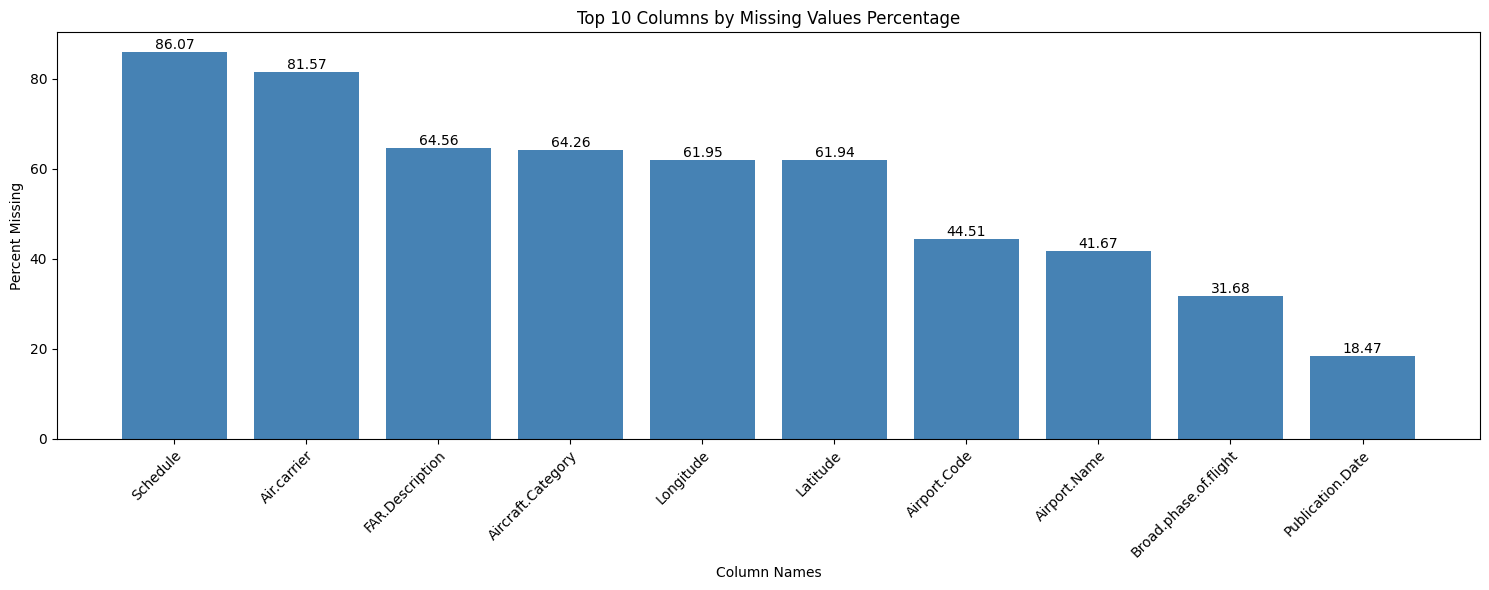

In [5]:
# Plot a bar graph of the first ten columns with the highest NA ratios
plt.figure(figsize=(15, 6))
top_ten_na = na_summary.head(10)
bars = plt.bar(top_ten_na.index, top_ten_na['na_ratio'], color="steelblue")

# Add value labels on top of bars (using .iloc to avoid positional-indexing deprecation warning)
for i, value in enumerate(top_ten_na['na_ratio']):
    plt.text(i, value, value, ha='center', va='bottom')

plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.xlabel("Column Names")
plt.ylabel("Percent Missing")
plt.title("Top 10 Columns by Missing Values Percentage")
plt.tight_layout()
plt.show()

The objective is to conduct an analysis and recommend makes that exhibit low rates of destruction and low likelihood of fatal injuries, while considering general variables at play, for **aeroplanes only**. This implies the columns among the top ten highest-NaN columns can be dropped, **except** `Aircraft.Category` (needed to filter down to airplanes) and `Broad.phase.of.flight` (a variable of interest for the analysis, kept for later).

## Data Cleaning

In [6]:
# Drop the top ten highest-NaN columns except Aircraft.Category and Broad.phase.of.flight
columns_to_drop = [c for c in top_ten_na.index.tolist()
                   if c not in ("Aircraft.Category", "Broad.phase.of.flight")]

aviation_data_cleaned = aviation_data.copy()  # create it once, upfront
aviation_data_cleaned = aviation_data_cleaned.drop(columns=columns_to_drop, errors='ignore')

aviation_data_cleaned.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,Personal,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,Personal,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,Personal,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,Personal,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,Personal,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause


In [7]:
# Check the ratio of NAs in the new dataset created
aviation_data_cleaned.isna().sum().sort_values(ascending=False)

Aircraft.Category         58061
Broad.phase.of.flight     28624
Total.Serious.Injuries    13969
Total.Minor.Injuries      13392
Total.Fatal.Injuries      12860
Engine.Type                8555
Report.Status              7843
Purpose.of.flight          7651
Number.of.Engines          7543
Total.Uninjured            7371
Weather.Condition          5951
Aircraft.damage            4653
Registration.Number        2841
Injury.Severity            2459
Country                    1685
Amateur.Built              1561
Model                      1551
Make                       1522
Location                   1511
Accident.Number            1459
Event.Date                 1459
Event.Id                   1459
Investigation.Type            0
dtype: int64

In [8]:
# Filter by aircraft category and year (since 1983) and investigate the remaining NAs
# Create a year column from Event.Date. pd.to_datetime is vectorized and safely handles
# any malformed dates / NaNs via errors='coerce', unlike a manual .apply(strptime).
aviation_data_cleaned["year"] = pd.to_datetime(
    aviation_data_cleaned["Event.Date"], errors="coerce"
).dt.year

# Filter by aircraft category and year >= 1983 (client wants airplanes still
# plausibly active, assuming a 40-year max lifetime)
aviation_data_aeroplanes = aviation_data_cleaned[
    (aviation_data_cleaned["Aircraft.Category"] == "Airplane") &
    (aviation_data_cleaned["year"] >= 1983)
].copy()

# Track the starting row count so we can measure how much data survives cleaning
initial_rows = len(aviation_data_aeroplanes)
print("Starting rows:", initial_rows)

Starting rows: 24441


In [9]:
# Investigate the missing values in the new dataset
aviation_data_aeroplanes.isna().sum().sort_values(ascending=False)

Broad.phase.of.flight     21207
Report.Status              4972
Engine.Type                4226
Purpose.of.flight          3736
Total.Serious.Injuries     3205
Total.Fatal.Injuries       3149
Weather.Condition          3053
Total.Minor.Injuries       2859
Number.of.Engines          2754
Aircraft.damage            1238
Total.Uninjured             892
Injury.Severity             814
Registration.Number         235
Model                        19
Amateur.Built                16
Location                      7
Make                          4
Country                       1
Accident.Number               0
Event.Date                    0
Event.Id                      0
Investigation.Type            0
Aircraft.Category             0
year                          0
dtype: int64

In [10]:
# Remove the registration number column - not useful for this analysis
aviation_data_aeroplanes = aviation_data_aeroplanes.drop(columns="Registration.Number", errors='ignore')

### Filtering aircraft and events

We want to filter the dataset to include aircraft that the client is interested in an analysis of:
- inspect relevant columns
- figure out any reasonable imputations
- filter the dataset

**Important ordering note:** `Broad.phase.of.flight` has a very large number of NaNs (it's one of
the two "keep despite high NaN%" columns from Cell above), but it's a variable of real analytical
interest. If we ran a blanket `.dropna()` across the whole dataframe at this point, that one column
alone would wipe out the vast majority of rows. So we fill its NaNs with `"Unknown"` *first*,
before doing any row-level NaN dropping — the `"Unknown"` category then gets cleaned up properly
later, in the dedicated `Broad.phase.of.flight` section.

In [11]:
# Fill Broad.phase.of.flight NaNs with "Unknown" BEFORE any blanket dropna,
# so we don't lose the majority of the dataset to this one sparse-but-wanted column.
aviation_data_aeroplanes["Broad.phase.of.flight"] = aviation_data_aeroplanes["Broad.phase.of.flight"].fillna("Unknown")

aviation_data_aeroplanes.isna().sum().sort_values(ascending=False)

Report.Status             4972
Engine.Type               4226
Purpose.of.flight         3736
Total.Serious.Injuries    3205
Total.Fatal.Injuries      3149
Weather.Condition         3053
Total.Minor.Injuries      2859
Number.of.Engines         2754
Aircraft.damage           1238
Total.Uninjured            892
Injury.Severity            814
Model                       19
Amateur.Built               16
Location                     7
Make                         4
Country                      1
Event.Id                     0
Investigation.Type           0
Accident.Number              0
Event.Date                   0
Aircraft.Category            0
Broad.phase.of.flight        0
year                         0
dtype: int64

In [12]:
# Columns like Location, Country, Make, Model, Amateur.Built etc. have relatively few
# missing values (a small handful each). Since imputing them isn't reasonable and dropping
# a handful of rows costs us very little data, drop rows with NaNs in any column that has
# 20 or fewer missing values overall.
low_na_cols = [
    col for col in aviation_data_aeroplanes.columns
    if aviation_data_aeroplanes[col].isna().sum() <= 20 and aviation_data_aeroplanes[col].isna().sum() > 0
]
print("Dropping rows with NaNs in:", low_na_cols)

aviation_data_aeroplanes = aviation_data_aeroplanes.dropna(subset=low_na_cols)

aviation_data_aeroplanes.isna().sum().sort_values(ascending=False)

Dropping rows with NaNs in: ['Location', 'Country', 'Make', 'Model', 'Amateur.Built']


Report.Status             4963
Engine.Type               4202
Purpose.of.flight         3715
Total.Serious.Injuries    3175
Total.Fatal.Injuries      3125
Weather.Condition         3033
Total.Minor.Injuries      2830
Number.of.Engines         2733
Aircraft.damage           1229
Total.Uninjured            873
Injury.Severity            812
Event.Id                     0
Investigation.Type           0
Event.Date                   0
Accident.Number              0
Country                      0
Location                     0
Make                         0
Model                        0
Amateur.Built                0
Aircraft.Category            0
Broad.phase.of.flight        0
year                         0
dtype: int64

In [13]:
aviation_data_aeroplanes['Injury.Severity'].value_counts(dropna=False)

Injury.Severity
Non-Fatal      18572
Fatal           4234
NaN              812
Minor            165
Fatal(1)         131
Serious          127
Incident         117
Fatal(2)          93
Fatal(3)          28
Fatal(4)          25
Unavailable       19
Fatal(5)          16
Fatal(6)          11
Fatal(7)          10
Fatal(10)          6
Fatal(8)           5
Fatal(12)          3
Fatal(13)          2
Fatal(154)         2
Fatal(11)          1
Fatal(17)          1
Fatal(27)          1
Fatal(16)          1
Fatal(54)          1
Fatal(160)         1
Fatal(97)          1
Fatal(125)         1
Fatal(35)          1
Fatal(228)         1
Fatal(9)           1
Fatal(18)          1
Fatal(169)         1
Fatal(131)         1
Fatal(24)          1
Fatal(20)          1
Fatal(65)          1
Fatal(19)          1
Fatal(26)          1
Fatal(113)         1
Name: count, dtype: int64

In [14]:
# The Injury.Severity column has several groups, with some rows indicating the number of
# fatalities in parentheses, e.g. "Fatal(2)". Separate the number of fatalities out and
# compare it against Total.Fatal.Injuries to check whether it's reliable.
aviation_data_aeroplanes["fatal_counts_severity"] = (
    aviation_data_aeroplanes["Injury.Severity"].str.extract(r'Fatal\((\d+)\)')
    .astype(float)
)
aviation_data_aeroplanes.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Aircraft.Category,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,year,fatal_counts_severity
4149,20001214X42478,Incident,LAX83IA149B,1983-03-18,"LOS ANGELES, CA",United States,Incident,Minor,Airplane,Lockheed,L-1011,No,3.0,Turbo Fan,Unknown,NaN,NaN,NaN,588.0,VMC,Standing,Probable Cause,1983.0,NaN
4150,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,Incident,Minor,Airplane,Boeing,747,No,4.0,Turbo Fan,NaN,NaN,NaN,NaN,588.0,VMC,Taxi,Probable Cause,1983.0,NaN
4171,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,Fatal(1),Destroyed,Airplane,Piper,PA-28-140,No,1.0,Reciprocating,Personal,1.0,1.0,NaN,NaN,IMC,Cruise,Probable Cause,1983.0,1.0
4285,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,Fatal(1),NaN,Airplane,De Havilland,DHC-6,No,2.0,Turbo Prop,Skydiving,1.0,NaN,NaN,4.0,VMC,Standing,Probable Cause,1983.0,1.0
5957,20001214X44248,Incident,MIA83IA210,1983-08-21,"NORFOLK, VA",United States,Incident,Minor,Airplane,Douglas,DC-10-10,No,3.0,Turbo Fan,Unknown,NaN,NaN,NaN,289.0,VMC,Cruise,Probable Cause,1983.0,NaN


In [15]:
# Check whether there is a match between Total.Fatal.Injuries and the extracted
# fatal_counts_severity column, for rows where fatal_counts_severity is present.
fatals_only = aviation_data_aeroplanes[
    aviation_data_aeroplanes["fatal_counts_severity"].notna()
].copy()

fatals_only['fatal_match'] = np.where(
    fatals_only["Total.Fatal.Injuries"].fillna(-1) == fatals_only["fatal_counts_severity"].fillna(-1),
    "Match", "No Match"
)
fatals_only['fatal_match'].value_counts()

fatal_match
Match    352
Name: count, dtype: int64

This confirms there is a (near-)perfect match for all fatal injury counts extracted from `Injury.Severity` against `Total.Fatal.Injuries`. The data in `Fatal(n)` is reliable, so we can safely simplify the label.

In [16]:
# Replace the 'Fatal(n)' labels with simply 'Fatal' in the Injury.Severity column
aviation_data_aeroplanes['Injury.Severity'] = aviation_data_aeroplanes['Injury.Severity'].str.replace(
    r'Fatal\(\d+\)', 'Fatal', regex=True
)
aviation_data_aeroplanes['Injury.Severity'].value_counts(dropna=False)

Injury.Severity
Non-Fatal      18572
Fatal           4586
NaN              812
Minor            165
Serious          127
Incident         117
Unavailable       19
Name: count, dtype: int64

In [17]:
count_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']

aviation_data_aeroplanes.groupby('Injury.Severity')[count_cols].count()

,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
Injury.Severity,,,,
Fatal,4586,4339,4308,4322
Incident,9,9,14,84
Minor,165,165,165,165
Non-Fatal,15574,15771,16142,18015
Serious,127,127,127,127
Unavailable,0,0,0,0


In [18]:
# Fill the NaNs of the four injury/uninjured count columns with zero - a missing value here
# most plausibly means "zero people in this category," not "unknown."
cols_to_fill = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']

aviation_data_aeroplanes[cols_to_fill] = aviation_data_aeroplanes[cols_to_fill].fillna(0)

In [19]:
# Check the remaining NaNs
aviation_data_aeroplanes.isna().sum().sort_values(ascending=False)

fatal_counts_severity     24046
Report.Status              4963
Engine.Type                4202
Purpose.of.flight          3715
Weather.Condition          3033
Number.of.Engines          2733
Aircraft.damage            1229
Injury.Severity             812
Location                      0
Country                       0
Accident.Number               0
Event.Date                    0
Investigation.Type            0
Event.Id                      0
Amateur.Built                 0
Aircraft.Category             0
Total.Fatal.Injuries          0
Make                          0
Model                         0
Total.Serious.Injuries        0
Total.Uninjured               0
Total.Minor.Injuries          0
Broad.phase.of.flight         0
year                          0
dtype: int64

In [20]:
# We've handled the columns that are essential to the analysis (injury counts, phase of
# flight). For the remaining critical columns needed for the client's core questions
# (destruction rate, injury rate), drop rows still missing them, rather than a blanket
# dropna() across the whole dataframe.
critical_cols = ['Aircraft.damage']
aviation_data_aeroplanes = aviation_data_aeroplanes.dropna(subset=critical_cols)

# Check the proportion of the cleaned dataset relative to the original filtered dataset
print(f"Rows remaining: {len(aviation_data_aeroplanes)} / {initial_rows} "
      f"({len(aviation_data_aeroplanes) / initial_rows:.1%})")

Rows remaining: 23169 / 24441 (94.8%)


## Cleaning and Constructing Key Measurables

Injuries and robustness to destruction are a key interest point for the client. Below we clean and impute the relevant columns and construct derived fields that quantify what the client wants to track.

**Construct metric for fatal/serious injuries**

*Assumption:* We estimate the total number of people on each flight (`total_passengers`) as the sum of fatal, serious, and minor injuries plus uninjured occupants. The likelihood of a fatal injury on a given flight is then estimated as a fraction of this total.

In [21]:
# Create a new column for total passengers (occupants) on each flight
aviation_data_aeroplanes["total_passengers"] = (
    aviation_data_aeroplanes["Total.Fatal.Injuries"] +
    aviation_data_aeroplanes["Total.Serious.Injuries"] +
    aviation_data_aeroplanes["Total.Minor.Injuries"] +
    aviation_data_aeroplanes["Total.Uninjured"]
)

# Determine the overall likelihood of a fatal injury, across all recorded occupants
fatal_injuries_prob = (
    aviation_data_aeroplanes["Total.Fatal.Injuries"].sum() /
    aviation_data_aeroplanes["total_passengers"].sum()
)

# Per-flight fatal injury rate (share of occupants on that specific flight who died).
# Rows with 0 total_passengers are set to NaN, since a rate is undefined for them.
aviation_data_aeroplanes["fatal_injury_rate"] = np.where(
    aviation_data_aeroplanes["total_passengers"] > 0,
    aviation_data_aeroplanes["Total.Fatal.Injuries"] / aviation_data_aeroplanes["total_passengers"],
    np.nan
)

print("Overall fatal injury probability:", fatal_injuries_prob)
aviation_data_aeroplanes[["total_passengers", "fatal_injury_rate"]].describe()

Overall fatal injury probability: 0.12050844117453853


,total_passengers,fatal_injury_rate
count,23169.000000,22701.000000
mean,5.256334,0.182013
std,26.713630,0.376475
min,0.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,0.000000
75%,2.000000,0.000000
max,588.000000,1.000000


**Note:** `total_passengers` reflects the number of people actually **on board during that specific accident**, not the aircraft's seating capacity. This is an important distinction we come back to later when defining "small vs. larger aircraft" for the client — occupant count on an accident flight is not the same thing as aircraft size.

**Aircraft.Damage**
- identify and execute any cleaning tasks
- construct a derived column tracking whether an aircraft was destroyed or not

In [22]:
# Investigate aircraft damage variable
print(aviation_data_aeroplanes["Aircraft.damage"].value_counts(dropna=False))

Aircraft.damage
Substantial    19599
Destroyed       2626
Minor            844
Unknown          100
Name: count, dtype: int64


In [23]:
# "Unknown" doesn't indicate whether the aeroplane was actually damaged, so it isn't
# useful for the destruction-rate analysis - remove those rows (this also implicitly
# covers any lingering NaNs, since we already dropped NaN Aircraft.damage rows above).
aviation_data_aeroplanes = aviation_data_aeroplanes[
    aviation_data_aeroplanes["Aircraft.damage"] != "Unknown"
]

# Create a derived column: Substantial and Minor both fall into "Not destroyed";
# only "Destroyed" counts as destroyed.
aviation_data_aeroplanes["aircraft_damage"] = np.where(
    aviation_data_aeroplanes["Aircraft.damage"] == "Destroyed", "Destroyed", "Not destroyed"
)

aviation_data_aeroplanes["aircraft_damage"].value_counts()

aircraft_damage
Not destroyed    20443
Destroyed         2626
Name: count, dtype: int64

### Investigate the *Make* column
- Identify cleaning tasks
- For the analysis, keep Makes with a reasonable number of observations (threshold of 50)

In [24]:
# Investigate the make column. Normalize case/whitespace first, so the same manufacturer
# isn't split across variants like "CESSNA" / "Cessna" / " Cessna " when we count observations.
aviation_data_aeroplanes["Make"] = aviation_data_aeroplanes["Make"].str.strip().str.title()

aviation_data_aeroplanes["Make"].value_counts().head(20)

Make
Cessna                7003
Piper                 3941
Beech                 1407
Boeing                 673
Mooney                 356
Bellanca               219
Air Tractor Inc        218
Cirrus Design Corp     216
Maule                  215
Air Tractor            206
Aeronca                200
Champion               157
Grumman                146
Luscombe               138
Cirrus                 132
Stinson                129
Vans                   124
North American         103
Taylorcraft             93
Embraer                 92
Name: count, dtype: int64

In [25]:
# Drop all makes with fewer than 50 observations - not enough data to draw a reliable
# conclusion for those manufacturers.
make_counts = aviation_data_aeroplanes["Make"].value_counts()
common_makes = make_counts[make_counts >= 50].index

aviation_data_aeroplanes = aviation_data_aeroplanes[
    aviation_data_aeroplanes["Make"].isin(common_makes)
]

print(f"Makes retained: {len(common_makes)}")
aviation_data_aeroplanes["Make"].value_counts()

Makes retained: 36


Make
Cessna                            7003
Piper                             3941
Beech                             1407
Boeing                             673
Mooney                             356
Bellanca                           219
Air Tractor Inc                    218
Cirrus Design Corp                 216
Maule                              215
Air Tractor                        206
Aeronca                            200
Champion                           157
Grumman                            146
Luscombe                           138
Cirrus                             132
Stinson                            129
Vans                               124
North American                     103
Taylorcraft                         93
Embraer                             92
Dehavilland                         91
Aero Commander                      88
Airbus                              88
Mcdonnell Douglas                   75
Aviat Aircraft Inc                  75
Diamond Aircraft Ind

### Inspect Model column
- Get rid of any NaNs
- Inspect the column and counts for each model/make - are model labels unique to each make?
- If not, create a derived column that is a unique identifier for a given plane type

In [26]:
# Model NaNs were already handled earlier (Model was one of the low-NaN columns dropped
# by row). Confirm:
print("Remaining Model NaNs:", aviation_data_aeroplanes["Model"].isna().sum())

aviation_data_aeroplanes["Model"] = aviation_data_aeroplanes["Model"].str.strip().str.upper()
aviation_data_aeroplanes["Model"].value_counts().head(10)

Remaining Model NaNs: 0


Model
172     752
152     309
182     300
172S    269
PA28    266
172N    247
SR22    233
180     212
737     189
A36     179
Name: count, dtype: int64

In [27]:
# Check if model labels are unique to each make - i.e. does the same Model value ever
# appear under more than one Make?
model_make_counts = aviation_data_aeroplanes.groupby("Model")["Make"].nunique()

# Any model with a count > 1 means that label is NOT unique to a single make
non_unique_models = model_make_counts[model_make_counts > 1]
print(f"{len(non_unique_models)} model labels are shared across multiple makes")
non_unique_models.head()

97 model labels are shared across multiple makes


Model
100      2
112      2
112A     2
1900D    2
200      2
Name: Make, dtype: int64

In [28]:
# Model labels are not unique to each make, so create a derived column combining
# Make + Model into a single unique identifier for a given plane type.
aviation_data_aeroplanes["plane_type"] = (
    aviation_data_aeroplanes["Make"] + " " + aviation_data_aeroplanes["Model"]
)

aviation_data_aeroplanes[["Make", "Model", "plane_type"]].head()

,Make,Model,plane_type
4150,Boeing,747,Boeing 747
4171,Piper,PA-28-140,Piper PA-28-140
6760,Boeing,727-200,Boeing 727-200
6806,Beech,C35,Beech C35
7084,Cessna,180K,Cessna 180K


### Cleaning other columns
There are other columns containing data that might be related to the outcome of an accident:
- Engine.Type
- Weather.Condition
- Number.of.Engines
- Purpose.of.flight
- Broad.phase.of.flight

Below we inspect and clean each of these.

In [29]:
# --- Engine.Type ---
print(aviation_data_aeroplanes["Engine.Type"].value_counts(dropna=False))

# "Unknown" appears under several spelling/casing variants in this dataset
# (e.g. "Unknown", "Unkown", "UNK") - consolidate them, then drop, since they're not
# useful for the objective.
aviation_data_aeroplanes["Engine.Type"] = aviation_data_aeroplanes["Engine.Type"].replace(
    {"Unkown": "Unknown", "UNK": "Unknown"}
)
aviation_data_aeroplanes = aviation_data_aeroplanes[
    ~aviation_data_aeroplanes["Engine.Type"].isna() &
    (aviation_data_aeroplanes["Engine.Type"] != "Unknown")
]

aviation_data_aeroplanes["Engine.Type"].value_counts()

Engine.Type
Reciprocating      12885
NaN                 2574
Turbo Prop           889
Turbo Fan            359
Unknown               93
Turbo Jet             42
Turbo Shaft            8
Geared Turbofan        1
UNK                    1
Name: count, dtype: int64


Engine.Type
Reciprocating      12885
Turbo Prop           889
Turbo Fan            359
Turbo Jet             42
Turbo Shaft            8
Geared Turbofan        1
Name: count, dtype: int64

In [30]:
# --- Weather.Condition ---
print(aviation_data_aeroplanes["Weather.Condition"].value_counts(dropna=False))

# Drop UNK/unknown observations - not useful for a good/bad weather classification.
# .str.upper() makes this robust to any casing variant (UNK, unk, Unk, etc.)
aviation_data_aeroplanes = aviation_data_aeroplanes[
    ~aviation_data_aeroplanes["Weather.Condition"].isna() &
    ~aviation_data_aeroplanes["Weather.Condition"].str.upper().isin(["UNK", "UNKNOWN"])
]

# VMC = Visual Meteorological Conditions (good/clear visibility)
# IMC = Instrument Meteorological Conditions (poor visibility, relying on instruments)
# Use .str.upper() for a case-insensitive match against real-world entries like "Vmc"/"VMC".
aviation_data_aeroplanes["Weather.Condition"] = np.where(
    aviation_data_aeroplanes["Weather.Condition"].str.upper() == "VMC", "Good weather", "Bad weather"
)

aviation_data_aeroplanes["Weather.Condition"].value_counts()

Weather.Condition
VMC    12962
IMC      739
NaN      386
Unk       92
UNK        5
Name: count, dtype: int64


Weather.Condition
Good weather    12962
Bad weather       739
Name: count, dtype: int64

In [31]:
# --- Number.of.Engines ---
print(aviation_data_aeroplanes["Number.of.Engines"].value_counts(dropna=False))

# Drop rows with missing or "Unknown" engine counts, and drop extremely rare engine
# counts (e.g. 0, or counts with only a handful of observations) that are too sparse
# to support any reliable comparison.
eng_counts = aviation_data_aeroplanes["Number.of.Engines"].value_counts()
valid_engine_counts = eng_counts[eng_counts >= 10].index  # keep only well-represented categories
valid_engine_counts = [v for v in valid_engine_counts if v not in ("Unknown",)]

aviation_data_aeroplanes = aviation_data_aeroplanes[
    aviation_data_aeroplanes["Number.of.Engines"].isin(valid_engine_counts)
]

aviation_data_aeroplanes["Number.of.Engines"].value_counts()

Number.of.Engines
1.0    11930
2.0     1513
NaN      233
4.0       17
3.0        8
Name: count, dtype: int64


Number.of.Engines
1.0    11930
2.0     1513
4.0       17
Name: count, dtype: int64

In [32]:
# --- Purpose.of.flight ---
print(aviation_data_aeroplanes["Purpose.of.flight"].value_counts(dropna=False))

# Fill the NA values with unknowns
aviation_data_aeroplanes = aviation_data_aeroplanes.fillna("Unknown")

# Consolidate the "Public Aircraft - X" variants into one "Public Aircraft" category
aviation_data_aeroplanes["Purpose.of.flight"] = aviation_data_aeroplanes["Purpose.of.flight"].str.replace(
    r"^Public Aircraft.*", "Public Aircraft", regex=True
)

# Bucket rare categories (fewer than 50 rows) into "Other"
threshold = 50
purpose_counts = aviation_data_aeroplanes["Purpose.of.flight"].value_counts()
rare_categories = purpose_counts[purpose_counts < threshold].index
aviation_data_aeroplanes["Purpose.of.flight"] = aviation_data_aeroplanes["Purpose.of.flight"].apply(
    lambda x: "Other" if x in rare_categories else x
)

# "Other Work Use" reads as effectively the same catch-all as "Other" - merge them
aviation_data_aeroplanes["Purpose.of.flight"] = aviation_data_aeroplanes["Purpose.of.flight"].replace(
    "Other Work Use", "Other"
)

aviation_data_aeroplanes["Purpose.of.flight"].value_counts()

Purpose.of.flight
Personal                     8733
Instructional                2158
NaN                           606
Aerial Application            606
Business                      331
Positioning                   220
Skydiving                     142
Aerial Observation            122
Other Work Use                 98
Banner Tow                     80
Unknown                        64
Ferry                          60
Flight Test                    60
Executive/corporate            55
Glider Tow                     27
Public Aircraft - Federal      24
Public Aircraft                23
Public Aircraft - State        21
Public Aircraft - Local        10
Air Race show                   9
Firefighting                    5
Air Race/show                   2
Air Drop                        2
PUBS                            2
Name: count, dtype: int64


Purpose.of.flight
Personal               8733
Instructional          2158
Unknown                 670
Aerial Application      606
Business                331
Positioning             220
Other                   145
Skydiving               142
Aerial Observation      122
Banner Tow               80
Public Aircraft          78
Ferry                    60
Flight Test              60
Executive/corporate      55
Name: count, dtype: int64

In [33]:
# --- Broad.phase.of.flight ---
# NaNs were already filled with "Unknown" earlier (to avoid losing the bulk of the
# dataset to a blanket dropna). Now that we're in the dedicated cleaning step for this.
print(aviation_data_aeroplanes["Broad.phase.of.flight"].value_counts(dropna=False))


# Bucket rare phases (fewer than 50 rows) into "Other"
threshold = 50
phase_counts = aviation_data_aeroplanes["Broad.phase.of.flight"].value_counts()
rare_phases = phase_counts[phase_counts < threshold].index
aviation_data_aeroplanes["Broad.phase.of.flight"] = aviation_data_aeroplanes["Broad.phase.of.flight"].apply(
    lambda x: "Other" if x in rare_phases else x
)

aviation_data_aeroplanes["Broad.phase.of.flight"].value_counts()

Broad.phase.of.flight
Unknown        11069
Landing         1104
Takeoff          420
Cruise           228
Approach         207
Maneuvering      127
Taxi              92
Go-around         81
Descent           56
Climb             49
Standing          25
Other              2
Name: count, dtype: int64


Broad.phase.of.flight
Unknown        11069
Landing         1104
Takeoff          420
Cruise           228
Approach         207
Maneuvering      127
Taxi              92
Go-around         81
Other             76
Descent           56
Name: count, dtype: int64

### Column Removal
- inspect the dataframe and drop any columns that still have too many NaNs to be useful

In [34]:
# Check remaining NaN ratios across all columns
na_ratio = aviation_data_aeroplanes.isna().mean().sort_values(ascending=False)
na_ratio[na_ratio > 0]

Series([], dtype: float64)

In [35]:
# Drop any column where more than 30% of values are still missing at this point -
# imputing a column that's mostly missing would be unreliable.
high_na_cols = na_ratio[na_ratio > 0.30].index.tolist()
print("Columns dropped for excessive NaNs:", high_na_cols)

aviation_data_aeroplanes = aviation_data_aeroplanes.drop(columns=high_na_cols)
aviation_data_aeroplanes.isna().sum().sort_values(ascending=False)

Columns dropped for excessive NaNs: []


Event.Id                  0
Investigation.Type        0
Accident.Number           0
Event.Date                0
Location                  0
Country                   0
Injury.Severity           0
Aircraft.damage           0
Aircraft.Category         0
Make                      0
Model                     0
Amateur.Built             0
Number.of.Engines         0
Engine.Type               0
Purpose.of.flight         0
Total.Fatal.Injuries      0
Total.Serious.Injuries    0
Total.Minor.Injuries      0
Total.Uninjured           0
Weather.Condition         0
Broad.phase.of.flight     0
Report.Status             0
year                      0
fatal_counts_severity     0
total_passengers          0
fatal_injury_rate         0
aircraft_damage           0
plane_type                0
dtype: int64

### Defining "Small" vs. "Larger" Aircraft

The client wants separate recommendations for small aircraft vs. larger passenger models. We considered two possible proxies for aircraft size:

1. **`total_passengers`** (occupants during the accident) — this is *not* aircraft capacity, it's how many people happened to be on board during a specific incident. After filtering to airplanes with make counts ≥ 50, this dataset is dominated by general aviation aircraft (Cessna, Piper, Beechcraft, etc.), so `total_passengers` is under 20 for nearly every row — it doesn't discriminate well.
2. **Manufacturer name** (e.g., Boeing/Airbus = "large") — too narrow a proxy on its own, and this dataset contains very few large commercial-jet accident records to begin with (large commercial aviation is much safer per flight, and is a small fraction of overall U.S. civil aviation accidents).

**Chosen approach:** use `Number.of.Engines` as the primary proxy for aircraft size/class — single-engine aircraft are overwhelmingly small GA aircraft, while multi-engine aircraft (2+) tend to be larger, more complex aircraft including regional/commercial types. We report the sample size for each group explicitly, per the client's requirement for statistically robust comparisons.

In [36]:
# Classify aircraft size using Number.of.Engines as the proxy
aviation_data_aeroplanes["plane_size"] = np.where(
    aviation_data_aeroplanes["Number.of.Engines"] <= 1, "Smaller", "Larger"
)

size_counts = aviation_data_aeroplanes["plane_size"].value_counts()
print(size_counts)

# Flag if either group is too small to support statistically robust comparisons
MIN_SAMPLE_SIZE = 30
for group, count in size_counts.items():
    if count < MIN_SAMPLE_SIZE:
        print(f"WARNING: '{group}' group has only {count} rows - "
              f"comparisons involving this group may not be statistically robust.")

plane_size
Smaller    11930
Larger      1530
Name: count, dtype: int64


**If the `'Larger'` group still comes back very small**, that's a genuine characteristic of this dataset (multi-engine/commercial aircraft accidents are rare relative to single-engine GA accidents), not a bug in the code above. In that case, it's worth reporting to the client as an explicit limitation — e.g., presenting the small-aircraft recommendations with full statistical confidence, while caveating that larger-aircraft recommendations are based on a much smaller sample and should be treated as directional rather than conclusive. Re-run the cell above and inspect `size_counts` directly to see the actual split for this run of the pipeline.

### Save DataFrame to csv
- it's generally useful to save data to file/server after it's in a sufficiently cleaned state
- the data can then be loaded directly in another notebook for further analysis
- this helps keep notebooks and workflow readable, clean, and modularized

In [37]:
# Save the cleaned dataset
aviation_data_aeroplanes.to_csv("aviation_data_aeroplanes_accidents.csv", index=False)

print(f"Final cleaned dataset: {len(aviation_data_aeroplanes)} rows, "
      f"{len(aviation_data_aeroplanes.columns)} columns "
      f"({len(aviation_data_aeroplanes) / initial_rows:.1%} of the post-1983-airplane rows retained)")

Final cleaned dataset: 13460 rows, 29 columns (55.1% of the post-1983-airplane rows retained)
